# TSV (Frozen Head) on OpenCLIP -- STL-10, Single Layers + All Layers, Small LR Grid

Same experiment as the trainable-head version, using a **frozen,
text-encoder-derived classifier** instead: `"a photo of a {class}"` for
each STL-10 class, embedded once and never updated. Only the TSV
vector(s) train.

**Each individual layer (12 configs) + all layers together (1 config) =
13 layer settings**, each tested at `[0.0001, 0.00005, 0.00001]`,
`EPOCHS=10` -- **39 runs total**.

Results save to their **own dedicated Drive folder**
(`PEFT_Results_STL10_TSV_Frozen`), separate from every other notebook's
results. Includes automatic per-run checkpointing and an explicit
Checkpoint Recovery cell for after a disconnect.

## 1. Setup and Installation

In [2]:
# Mount Google Drive (needed later for saving results, and if your
# professor's dataset folder is shared into your own Drive)
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
try:
    import gdown
    print("Required packages already present, skipping install.")
except ImportError:
    import subprocess
    import sys

    packages = [
        'transformers',
        'torch',
        'torchvision',
        'accelerate',
        'datasets',
        'numpy',
        'matplotlib',
        'tqdm',
        'scikit-learn',
        'gdown',
    ]

    print("Installing required packages...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade'] + packages)
    print("Installation complete!")


Required packages already present, skipping install.


In [4]:
# Verify GPU availability
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


PyTorch version: 2.11.0+cu128
GPU available: True
GPU name: NVIDIA A100-SXM4-40GB
GPU memory: 42.41 GB


## 2. Import Libraries and Setup

In [5]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import json
from datetime import datetime

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


## 3. Data Preparation (STL-10)

Same pattern as the CIFAR-10 notebook: pull the dataset from a **Google
Drive folder ID** (yours, since you've already saved STL-10 there
yourself), instead of downloading from the official Stanford source
every time.

**Before running this**, set `folder_id` below to your own Drive
folder's shareable ID (the STL-10 folder you already uploaded).

Note: since this is *your own* Drive (not someone else's shared link),
you don't strictly need `gdown` here -- a mounted Drive is already
directly accessible by path. This uses `gdown` anyway to match the exact
same retrieval style as the CIFAR-10 notebook, in case that's preferred
for consistency.

In [6]:
import os
import shutil

# Set this to YOUR Drive folder's shareable ID (the one containing the
# stl10_binary folder / files you already uploaded)
folder_id = 'YOUR_STL10_DRIVE_FOLDER_ID_HERE'

# NOTE: this notebook does NOT write a cached copy back to this Drive
# account -- it only READS an existing cache if one is already there
# (e.g. on a different account that does cache). This keeps
# storage-constrained Drive accounts from silently accumulating cached
# dataset copies every time this notebook runs.
DRIVE_CACHE_DIR = '/content/drive/MyDrive/stl10_cache'
DRIVE_CACHE_PATH = os.path.join(DRIVE_CACHE_DIR, 'stl10_binary')

LOCAL_DATA_DIR = 'data'
LOCAL_CACHE_PATH = os.path.join(LOCAL_DATA_DIR, 'stl10_binary')

os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

if os.path.exists(LOCAL_CACHE_PATH):
    # Already unpacked on THIS session's local disk -- nothing to do.
    print(f"Already present locally at {LOCAL_CACHE_PATH}, skipping.")

elif os.path.exists(DRIVE_CACHE_PATH):
    # Read-only fast path -- only taken if a cache already exists on this
    # Drive account. This notebook never CREATES that cache itself.
    print("Found an existing cached copy on this Drive -- copying to local disk...")
    shutil.copytree(DRIVE_CACHE_PATH, LOCAL_CACHE_PATH)
    print(f"Copied to {LOCAL_CACHE_PATH}")

else:
    # Download from the shared Drive folder -- stays on the LOCAL
    # (temporary) Colab disk only. Nothing gets written back to this
    # Drive account, so its storage quota is never touched.
    print("Downloading from the shared Drive folder (local disk only -- "
          "not cached to this Drive account)...")
    !gdown --folder --id {folder_id}

    # See exactly what landed on disk before assuming a folder name --
    # if your Drive folder isn't literally named 'stl10_binary', update
    # `downloaded_name` below to match what gets printed here.
    print("Downloaded contents of current directory:", os.listdir('.'))
    downloaded_name = 'stl10_binary'

    if not os.path.exists(downloaded_name):
        raise FileNotFoundError(
            f"Couldn't find '{downloaded_name}' after download. Check the "
            f"directory listing printed above and update `downloaded_name` "
            f"to match what actually got downloaded."
        )

    # Move into place for torchvision -- LOCAL disk only, will be lost
    # when this runtime ends (that's expected -- re-download next session).
    shutil.move(downloaded_name, LOCAL_CACHE_PATH)
    print(f"Moved to {LOCAL_CACHE_PATH} (local disk only -- lost when this runtime ends)")

print("\nFinal local data contents:", os.listdir(LOCAL_DATA_DIR))


Found an existing cached copy on this Drive -- copying to local disk...
Copied to data/stl10_binary

Final local data contents: ['stl10_binary']


In [7]:
# Define data transformations (STL-10 stats; images are 96x96 natively --
# the training loop resizes everything to 224x224 for the ViT regardless,
# same resize_images() function used for CIFAR-10)
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(96, padding=12),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4467, 0.4398, 0.4066],
        std=[0.2603, 0.2566, 0.2713]
    )
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4467, 0.4398, 0.4066],
        std=[0.2603, 0.2566, 0.2713]
    )
])

# Load STL-10 dataset -- download=False, data is already local from the
# Drive-cache cell above
print("Loading STL-10 dataset from local ./data ...")
train_dataset_full = datasets.STL10(
    root='./data',
    split='train',
    download=False,
    transform=transform_train
)

test_dataset_full = datasets.STL10(
    root='./data',
    split='test',
    download=False,
    transform=transform_test
)

# STL-10's labeled train split is already exactly 5,000 images -- no
# subsampling needed there (unlike CIFAR-10's 50,000-image train set).
# Test set (8,000 images) gets subsampled to 1,000, matching the CIFAR-10
# notebooks' convention for speed and comparability.
train_dataset = train_dataset_full
subset_size_train = len(train_dataset)

subset_size_test = 1000
test_dataset, _ = random_split(
    test_dataset_full,
    [subset_size_test, len(test_dataset_full) - subset_size_test]
)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Number of classes: 10")
print(f"Input shape: (3, 96, 96) natively, resized to 224x224 for the model")


Loading STL-10 dataset from local ./data ...
Train dataset size: 5000
Test dataset size: 1000
Number of classes: 10
Input shape: (3, 96, 96) natively, resized to 224x224 for the model


In [8]:
# Create data loaders
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")


Train batches: 79
Test batches: 16


## 4. Training and Evaluation Functions

In [9]:
def resize_images(images, target_size=224):
    """Resize CIFAR-10 images (32x32) to target size for ViT"""
    from torchvision.transforms import Resize
    resizer = Resize((target_size, target_size))
    return resizer(images)

def train_epoch(model, train_loader, optimizer, criterion, device, epoch, total_epochs):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{total_epochs}", leave=False)

    for images, labels in pbar:
        # Resize images for ViT
        images = resize_images(images, target_size=224)
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        logits = model(images)
        loss = criterion(logits, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        total_loss += loss.item()
        _, predicted = logits.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

        # Update progress bar
        pbar.set_postfix({
            'loss': total_loss / (total / BATCH_SIZE),
            'acc': 100 * correct / total
        })

    return total_loss / len(train_loader), 100 * correct / total

def evaluate(model, test_loader, criterion, device):
    """Evaluate model on test set"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(test_loader, desc="Evaluating", leave=False)
        for images, labels in pbar:
            # Resize images for ViT
            images = resize_images(images, target_size=224)
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            _, predicted = logits.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    f1 = f1_score(all_labels, all_preds, average='weighted')

    return total_loss / len(test_loader), accuracy, f1

def count_parameters(model):
    """Count trainable and total parameters"""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total

print("Training and evaluation functions defined!")


Training and evaluation functions defined!


## 4.1 Global hyperparameters and dedicated results folder

In [10]:
from datetime import datetime as _dt
from pathlib import Path

EPOCHS = 10
LR_GRID = [0.0001, 0.00005, 0.00001]
DATASET_NAME = 'stl10'

RESULTS_DIR = Path('/content/drive/MyDrive/PEFT_Results_STL10_TSV_Frozen')
RESULTS_DIR.mkdir(exist_ok=True)

RUN_TIMESTAMP = _dt.now().strftime('%Y%m%d_%H%M%S')

def save_name(base_name, ext):
    return f"{base_name}_{DATASET_NAME}_{RUN_TIMESTAMP}.{ext}"

CHECKPOINT_PATH = RESULTS_DIR / f'tsv_frozen_singles_all_INPROGRESS_{DATASET_NAME}.json'

print(f"EPOCHS = {EPOCHS}")
print(f"LR_GRID = {LR_GRID}")
print(f"Results folder: {RESULTS_DIR}")
print(f"Checkpoint file: {CHECKPOINT_PATH.name}")


EPOCHS = 10
LR_GRID = [0.0001, 5e-05, 1e-05]
Results folder: /content/drive/MyDrive/PEFT_Results_STL10_TSV_Frozen
Checkpoint file: tsv_frozen_singles_all_INPROGRESS_stl10.json


## 5. TSV Infrastructure (Backbone Inspection, Hook Manager, Model Classes)

In [11]:
from transformers import CLIPVisionModel

# OpenCLIP ViT-B/32 weights, hosted on the HF Hub and loadable via `transformers`
OPENCLIP_MODEL_NAME = 'laion/CLIP-ViT-B-32-laion2B-s34B-b79K'

# Load ONCE, just to inspect the module tree -- this tells us the exact
# attribute path to the transformer blocks (same exercise as timm's
# `model.blocks[i]` vs HF ViT's `model.vit.layers[i]`, but for CLIP).
_probe = CLIPVisionModel.from_pretrained(OPENCLIP_MODEL_NAME)
print(_probe)


config.json:   0%|          | 0.00/4.36k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: laion/CLIP-ViT-B-32-laion2B-s34B-b79K
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11

CLIPVisionModel(
  (embeddings): CLIPVisionEmbeddings(
    (patch_embedding): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (position_embedding): Embedding(50, 768)
  )
  (pre_layrnorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (encoder): CLIPEncoder(
    (layers): ModuleList(
      (0-11): 12 x CLIPEncoderLayer(
        (self_attn): CLIPAttention(
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (out_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): CLIPMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
        )
        (

In [12]:
# Reading the tree printed above: CLIPVisionModel -> encoder -> layers[i]
# (NOTE: this is specific to the current `transformers` version. Older
# versions wrapped it as `model.vision_model.encoder.layers[i]` instead --
# always confirm with print(model) rather than assuming the path.)
print(_probe.encoder.layers[0])

# Done inspecting -- free the memory before building the real model below.
del _probe


CLIPEncoderLayer(
  (self_attn): CLIPAttention(
    (k_proj): Linear(in_features=768, out_features=768, bias=True)
    (v_proj): Linear(in_features=768, out_features=768, bias=True)
    (q_proj): Linear(in_features=768, out_features=768, bias=True)
    (out_proj): Linear(in_features=768, out_features=768, bias=True)
  )
  (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (mlp): CLIPMLP(
    (activation_fn): GELUActivation()
    (fc1): Linear(in_features=768, out_features=3072, bias=True)
    (fc2): Linear(in_features=3072, out_features=768, bias=True)
  )
  (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)


In [13]:
def get_transformer_blocks(model):
    """
    Return the list/ModuleList of transformer blocks for common ViT/CLIP
    implementations, so the rest of the code doesn't care which library the
    backbone came from.

    Covers:
      - timm ViT:                        model.blocks[i]
      - HF ViTModel:                      model.vit.layers[i]
      - HF CLIPVisionModel (current):     model.encoder.layers[i]
      - HF CLIPVisionModel (older ver.):  model.vision_model.encoder.layers[i]
      - open_clip (the `open_clip` pip package): model.visual.transformer.resblocks[i]
    """
    if hasattr(model, 'blocks'):                                        # timm
        return model.blocks
    if hasattr(model, 'vit') and hasattr(model.vit, 'layers'):           # HF ViTForImageClassification
        return model.vit.layers
    if hasattr(model, 'vision_model'):                                   # HF CLIPVisionModel (older versions)
        return model.vision_model.encoder.layers
    if hasattr(model, 'encoder') and hasattr(model.encoder, 'layers'):   # HF CLIPVisionModel (current) / generic
        return model.encoder.layers
    if hasattr(model, 'visual') and hasattr(model.visual, 'transformer'):  # open_clip package
        return model.visual.transformer.resblocks
    if hasattr(model, 'backbone'):                                       # our own wrapper classes
        return get_transformer_blocks(model.backbone)
    raise ValueError(
        "Could not auto-detect transformer blocks. "
        "Run print(model) and locate the block list manually."
    )


class TSVHookManager(nn.Module):
    """
    Registers forward hooks that add a trainable steering vector `v`
    (scaled by `lam`) to the output of chosen transformer blocks.

    where:
        'residual'      -> add v to the WHOLE block's output (default, matches the TSV paper)
        'attn'          -> add v only to the self-attention sub-module's output
        'mlp'           -> add v only to the MLP sub-module's output
        'attn_mlp'      -> two separate vectors, one after attn, one after mlp
        'attn_residual' -> two separate vectors, one after attn, one after the whole block's output
        'mlp_residual'  -> two separate vectors, one after mlp, one after the whole block's output

    layer_indices:
        list of block indices to steer, e.g. [4] for a single early-middle
        layer, or list(range(num_layers)) to steer every layer.
    """
    def __init__(self, model, layer_indices, hidden_dim, lam=5.0, where='residual'):
        super().__init__()
        self.lam = lam
        self.where = where
        self._hook_handles = []
        self.tsv_vectors = nn.ParameterDict()

        blocks = get_transformer_blocks(model)

        for idx in layer_indices:
            block = blocks[idx]

            if where == 'residual':
                v = nn.Parameter(torch.zeros(hidden_dim))
                self.tsv_vectors[f'layer{idx}_res'] = v
                self._hook_handles.append(block.register_forward_hook(self._make_hook(v)))

            elif where == 'attn':
                sub = self._find_submodule(block, ['attn', 'attention', 'self_attn'])
                v = nn.Parameter(torch.zeros(hidden_dim))
                self.tsv_vectors[f'layer{idx}_attn'] = v
                self._hook_handles.append(sub.register_forward_hook(self._make_hook(v)))

            elif where == 'mlp':
                sub = self._find_submodule(block, ['mlp', 'feed_forward', 'ffn'])
                v = nn.Parameter(torch.zeros(hidden_dim))
                self.tsv_vectors[f'layer{idx}_mlp'] = v
                self._hook_handles.append(sub.register_forward_hook(self._make_hook(v)))

            elif where == 'attn_mlp':
                attn_sub = self._find_submodule(block, ['attn', 'attention', 'self_attn'])
                mlp_sub = self._find_submodule(block, ['mlp', 'feed_forward', 'ffn'])
                v_attn = nn.Parameter(torch.zeros(hidden_dim))
                v_mlp = nn.Parameter(torch.zeros(hidden_dim))
                self.tsv_vectors[f'layer{idx}_attn'] = v_attn
                self.tsv_vectors[f'layer{idx}_mlp'] = v_mlp
                self._hook_handles.append(attn_sub.register_forward_hook(self._make_hook(v_attn)))
                self._hook_handles.append(mlp_sub.register_forward_hook(self._make_hook(v_mlp)))

            elif where == 'attn_residual':
                attn_sub = self._find_submodule(block, ['attn', 'attention', 'self_attn'])
                v_attn = nn.Parameter(torch.zeros(hidden_dim))
                v_res = nn.Parameter(torch.zeros(hidden_dim))
                self.tsv_vectors[f'layer{idx}_attn'] = v_attn
                self.tsv_vectors[f'layer{idx}_res'] = v_res
                self._hook_handles.append(attn_sub.register_forward_hook(self._make_hook(v_attn)))
                self._hook_handles.append(block.register_forward_hook(self._make_hook(v_res)))

            elif where == 'mlp_residual':
                mlp_sub = self._find_submodule(block, ['mlp', 'feed_forward', 'ffn'])
                v_mlp = nn.Parameter(torch.zeros(hidden_dim))
                v_res = nn.Parameter(torch.zeros(hidden_dim))
                self.tsv_vectors[f'layer{idx}_mlp'] = v_mlp
                self.tsv_vectors[f'layer{idx}_res'] = v_res
                self._hook_handles.append(mlp_sub.register_forward_hook(self._make_hook(v_mlp)))
                self._hook_handles.append(block.register_forward_hook(self._make_hook(v_res)))

            else:
                raise ValueError(f"Unknown 'where' option: {where}")

    def _make_hook(self, v):
        def hook(module, inputs, output):
            # Some sub-modules (e.g. attention) return a tuple like
            # (hidden_states, attn_weights); only steer the hidden_states.
            if isinstance(output, tuple):
                hidden_states = output[0] + self.lam * v
                return (hidden_states,) + output[1:]
            return output + self.lam * v
        return hook

    @staticmethod
    def _find_submodule(block, candidate_names):
        for name in candidate_names:
            if hasattr(block, name):
                return getattr(block, name)
        raise AttributeError(
            f"None of {candidate_names} found on block. "
            f"Inspect it with print(block) to find the right attribute name."
        )

    def remove_hooks(self):
        for h in self._hook_handles:
            h.remove()
        self._hook_handles = []

print("get_transformer_blocks() and TSVHookManager (6 placement modes) defined!")


get_transformer_blocks() and TSVHookManager (6 placement modes) defined!


In [14]:
class TSVClassificationModel(nn.Module):
    """
    Frozen OpenCLIP ViT-B/32 vision tower + trainable TSV steering vector(s)
    + a trainable linear classification head.

    Only `self.tsv` and `self.classifier` show up in trainable_parameters() --
    the backbone itself is entirely frozen, same spirit as PEFT, but the
    'adapter' here is a steering vector added to the residual stream instead
    of a low-rank update to a Linear layer.
    """
    def __init__(self, model_name=OPENCLIP_MODEL_NAME, num_classes=10,
                 layer_indices=None, lam=5.0, where='residual'):
        super().__init__()
        self.backbone = CLIPVisionModel.from_pretrained(model_name)
        self.hidden_size = self.backbone.config.hidden_size
        num_layers = self.backbone.config.num_hidden_layers

        # Freeze the ENTIRE backbone
        for p in self.backbone.parameters():
            p.requires_grad = False

        # Default: one early-middle layer, matching the TSV paper's finding
        # that layers ~4-10 (out of ~12-32) work best for steering.
        if layer_indices is None:
            layer_indices = [num_layers // 3]

        self.tsv = TSVHookManager(
            self.backbone, layer_indices, self.hidden_size,
            lam=lam, where=where
        )

        self.classifier = nn.Linear(self.hidden_size, num_classes)

    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values)
        cls_output = outputs.last_hidden_state[:, 0, :]  # CLS / class token, final layer
        logits = self.classifier(cls_output)
        return logits

    def trainable_parameters(self):
        return list(self.tsv.parameters()) + list(self.classifier.parameters())

print("TSVClassificationModel defined!")


TSVClassificationModel defined!


In [15]:
from transformers import CLIPModel, CLIPTokenizer

STL10_CLASSES = ['airplane', 'bird', 'car', 'cat', 'deer',
                  'dog', 'horse', 'monkey', 'ship', 'truck']


class TSVClassificationModelFrozenHead(nn.Module):
    """
    Frozen OpenCLIP ViT-B/32 vision tower + trainable TSV steering vector(s)
    + a FROZEN classifier head built from CLIP's own text encoder.

    Unlike TSVClassificationModel, NOTHING here is trained except the TSV
    vector(s) -- not the backbone, and not the head (there's no nn.Linear
    at all; classification is cosine similarity against fixed text
    embeddings, exactly how CLIP zero-shot classification works).
    """
    def __init__(self, model_name=OPENCLIP_MODEL_NAME, class_names=STL10_CLASSES,
                 layer_indices=None, lam=5.0, where='residual'):
        super().__init__()
        self.clip = CLIPModel.from_pretrained(model_name)
        self.hidden_size = self.clip.vision_model.config.hidden_size
        num_layers = self.clip.vision_model.config.num_hidden_layers

        # Freeze EVERYTHING in the pretrained CLIP model -- vision tower,
        # text tower, both projection layers, logit_scale. Only the TSV
        # vector(s) added below will ever be trainable.
        for p in self.clip.parameters():
            p.requires_grad = False

        if layer_indices is None:
            layer_indices = [num_layers // 3]

        # TSV hooks go on the vision tower only -- text tower is untouched
        self.tsv = TSVHookManager(
            self.clip.vision_model, layer_indices, self.hidden_size,
            lam=lam, where=where
        )

        # Build the frozen, text-encoder-derived classifier weights ONCE
        tokenizer = CLIPTokenizer.from_pretrained(model_name)
        prompts = [f"a photo of a {c}" for c in class_names]
        clip_device = next(self.clip.parameters()).device
        text_inputs = tokenizer(prompts, padding=True, return_tensors="pt").to(clip_device)
        with torch.no_grad():
            text_outputs = self.clip.get_text_features(**text_inputs)
            text_features = text_outputs.pooler_output  # projected text embedding lives here,
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)  # not on the returned object directly
        self.register_buffer('text_embeds', text_features)  # frozen, never trained

    def forward(self, pixel_values):
        # This call runs through self.clip.vision_model, whose layers have
        # our TSV forward hooks registered -- steering is applied here
        # exactly as in the trainable-head version.
        vision_outputs = self.clip.vision_model(pixel_values=pixel_values)
        pooled = vision_outputs.pooler_output  # CLIP's own post_layernorm(CLS token)
        image_features = self.clip.visual_projection(pooled)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        logits = self.clip.logit_scale.exp() * image_features @ self.text_embeds.T
        return logits

    def trainable_parameters(self):
        return list(self.tsv.parameters())  # ONLY the TSV vector(s) -- nothing else


print("TSVClassificationModelFrozenHead defined -- backbone AND head both frozen, only TSV trains.")


TSVClassificationModelFrozenHead defined -- backbone AND head both frozen, only TSV trains.


In [16]:
# Lightweight probe (not a full training run) just to read num_layers
_probe_for_layers = TSVClassificationModel(model_name=OPENCLIP_MODEL_NAME, num_classes=10,
                                            layer_indices=[0], lam=0.0, where='residual')
num_layers = _probe_for_layers.backbone.config.num_hidden_layers
del _probe_for_layers
torch.cuda.empty_cache()

# ONLY single layers + all layers together -- no pairs, triples, or halves
layer_groups = {}
for L in range(1, num_layers + 1):
    layer_groups[f'L{L}'] = [L - 1]
layer_groups[f'All(L1-{num_layers})'] = list(range(num_layers))

print(f"Layer settings to test: {len(layer_groups)} ({num_layers} single layers + 1 all-layers)")
print(f"Learning rates: {len(LR_GRID)}")
print(f"Total runs: {len(layer_groups)} x {len(LR_GRID)} = {len(layer_groups) * len(LR_GRID)}")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: laion/CLIP-ViT-B-32-laion2B-s34B-b79K
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11

Layer settings to test: 13 (12 single layers + 1 all-layers)
Learning rates: 3
Total runs: 13 x 3 = 39


In [17]:
import time

def run_tsv_experiment_frozen(layer_indices, where, lam, epochs, lr, train_loader_to_use=None, verbose=True):
    """Same idea as run_tsv_experiment(), but uses the frozen text-encoder head."""
    loader = train_loader_to_use if train_loader_to_use is not None else train_loader

    m = TSVClassificationModelFrozenHead(model_name=OPENCLIP_MODEL_NAME, class_names=STL10_CLASSES,
                                          layer_indices=layer_indices, lam=lam, where=where).to(device)
    opt = optim.AdamW(m.trainable_parameters(), lr=lr, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()

    start = time.time()
    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(m, loader, opt, crit, device, epoch, epochs)
        if verbose:
            print(f"      epoch {epoch+1}/{epochs}: train_loss={train_loss:.4f}  train_acc={train_acc:.2f}%")
    elapsed = time.time() - start

    _, test_acc, test_f1 = evaluate(m, test_loader, crit, device)
    trainable_params = sum(p.numel() for p in m.trainable_parameters())

    del m, opt
    torch.cuda.empty_cache()

    result = {'layer_indices': layer_indices, 'where': where, 'lam': lam, 'lr': lr,
              'test_acc': test_acc, 'test_f1': test_f1,
              'trainable_params': trainable_params, 'time_seconds': elapsed}
    if verbose:
        print(f"    layers={layer_indices}  lr={lr}  -> acc={test_acc:.2f}%  f1={test_f1:.4f}  ({elapsed:.1f}s)")
    return result


## Checkpoint Recovery

**Run this cell first, every time** -- whether starting fresh or
recovering after a disconnect.

In [18]:
import json

if CHECKPOINT_PATH.exists():
    with open(CHECKPOINT_PATH) as f:
        results = json.load(f)
    completed = {(tuple(r['layer_indices']), r['lr']) for r in results}
    print(f"CHECKPOINT FOUND -- recovering {len(results)} / {len(layer_groups)*len(LR_GRID)} runs already completed.")
    print("Already done:")
    for r in results:
        print(f"  {r['layer_indices']}  lr={r['lr']}  -> acc={r['test_acc']:.2f}%")
else:
    results = []
    completed = set()
    print("No in-progress checkpoint found -- starting fresh.")


No in-progress checkpoint found -- starting fresh.


### Phase: Single Layers + All Layers x Learning Rate Sweep (39 runs, FROZEN HEAD, `where='residual'`, `lam=5.0` fixed, `EPOCHS=10`)

In [19]:
print("="*70)
print(f"SWEEP (FROZEN HEAD): {len(layer_groups)} layer settings x {len(LR_GRID)} learning rates "
      f"= {len(layer_groups)*len(LR_GRID)} runs  (epochs={EPOCHS})")
print("="*70)

sweep_start = time.time()
for name, layers in layer_groups.items():
    for lr in LR_GRID:
        if (tuple(layers), lr) in completed:
            continue
        print(f"\n--- {name}  (layer_indices={layers}, lr={lr}) ---")
        result = run_tsv_experiment_frozen(layer_indices=layers, where='residual', lam=5.0, epochs=EPOCHS, lr=lr)
        result['name'] = name
        results.append(result)
        with open(CHECKPOINT_PATH, 'w') as f:
            json.dump(results, f, indent=2)

sweep_elapsed = time.time() - sweep_start
print(f"\nTotal sweep time: {sweep_elapsed/60:.1f} minutes")

best_result = max(results, key=lambda r: r['test_acc'])
print(f"\nBest: {best_result['name']} (layers={best_result['layer_indices']}), lr={best_result['lr']} "
      f"-> {best_result['test_acc']:.2f}% acc")


SWEEP (FROZEN HEAD): 13 layer settings x 3 learning rates = 39 runs  (epochs=10)

--- L1  (layer_indices=[0], lr=0.0001) ---


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/904 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

...

      epoch 7/10: train_loss=0.0674  train_acc=97.68%


      epoch 8/10: train_loss=0.0674  train_acc=97.78%


      epoch 9/10: train_loss=0.0667  train_acc=97.96%


      epoch 10/10: train_loss=0.0616  train_acc=97.92%


    layers=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]  lr=1e-05  -> acc=97.40%  f1=0.9739  (84.8s)

Total sweep time: 48.2 minutes

Best: All(L1-12) (layers=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), lr=5e-05 -> 98.20% acc


### Results and Plots

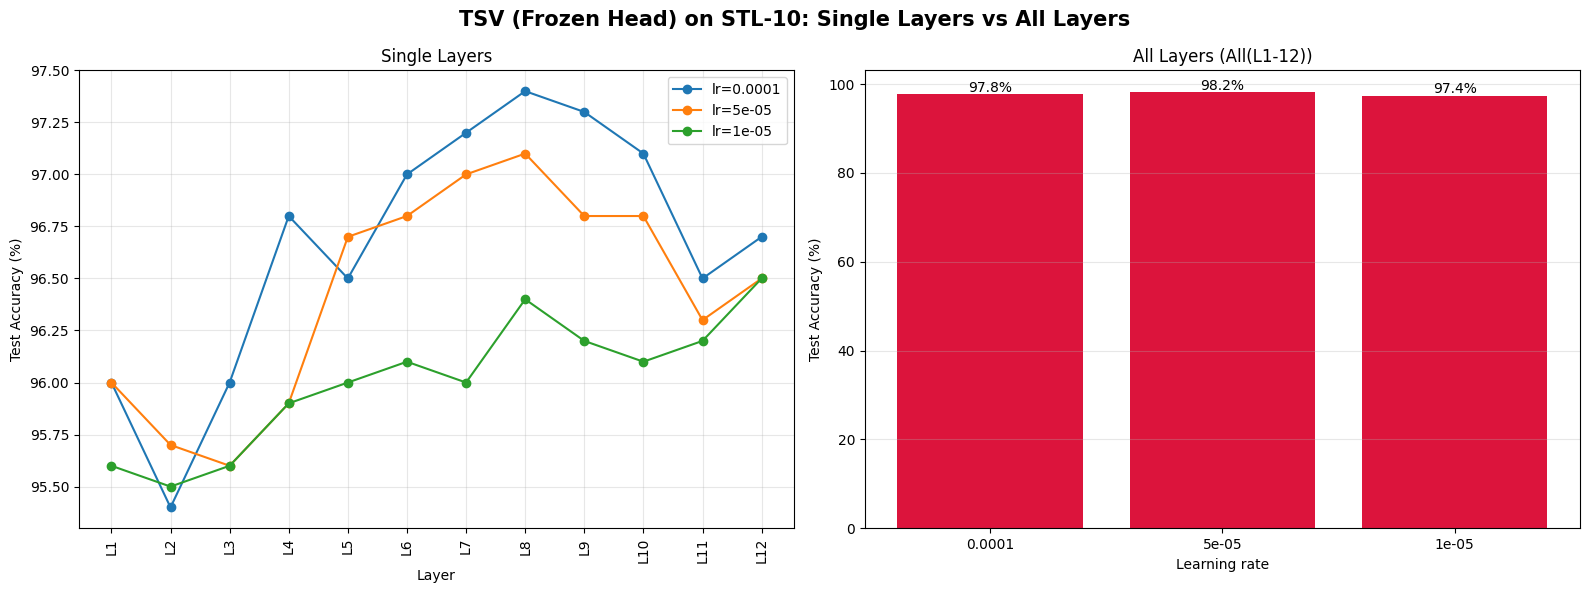


All results, sorted by accuracy:
  All(L1-12)      lr=5e-05      acc=98.20%  f1=0.9820
  All(L1-12)      lr=0.0001     acc=97.80%  f1=0.9780
  L8              lr=0.0001     acc=97.40%  f1=0.9740
  All(L1-12)      lr=1e-05      acc=97.40%  f1=0.9739
  L9              lr=0.0001     acc=97.30%  f1=0.9731
  L7              lr=0.0001     acc=97.20%  f1=0.9720
  L8              lr=5e-05      acc=97.10%  f1=0.9709
  L10             lr=0.0001     acc=97.10%  f1=0.9710
  L6              lr=0.0001     acc=97.00%  f1=0.9699
  L7              lr=5e-05      acc=97.00%  f1=0.9700
  L4              lr=0.0001     acc=96.80%  f1=0.9680
  L6              lr=5e-05      acc=96.80%  f1=0.9680
  L9              lr=5e-05      acc=96.80%  f1=0.9679
  L10             lr=5e-05      acc=96.80%  f1=0.9679
  L5              lr=5e-05      acc=96.70%  f1=0.9669
  L12             lr=0.0001     acc=96.70%  f1=0.9670
  L5              lr=0.0001     acc=96.50%  f1=0.9649
  L11             lr=0.0001     acc=96.50%  f1=0

In [20]:
singles_results = [r for r in results if r['name'].startswith('L') and 'All' not in r['name']]
all_layers_results = [r for r in results if r['name'].startswith('All')]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('TSV (Frozen Head) on STL-10: Single Layers vs All Layers', fontsize=15, fontweight='bold')

names_order = list(dict.fromkeys(r['name'] for r in singles_results))
for lr in LR_GRID:
    ys = [next(r['test_acc'] for r in singles_results if r['name'] == n and r['lr'] == lr) for n in names_order]
    axes[0].plot(names_order, ys, marker='o', label=f'lr={lr}')
axes[0].set_title('Single Layers')
axes[0].set_xlabel('Layer'); axes[0].set_ylabel('Test Accuracy (%)')
axes[0].tick_params(axis='x', rotation=90); axes[0].grid(True, alpha=0.3)
axes[0].legend()

all_name = all_layers_results[0]['name']
bar_lrs = [str(r['lr']) for r in all_layers_results]
bar_accs = [r['test_acc'] for r in all_layers_results]
bars = axes[1].bar(bar_lrs, bar_accs, color='crimson')
axes[1].set_title(f'All Layers ({all_name})')
axes[1].set_xlabel('Learning rate'); axes[1].set_ylabel('Test Accuracy (%)')
axes[1].grid(True, alpha=0.3, axis='y')
for b in bars:
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{b.get_height():.1f}%', ha='center')

plt.tight_layout()
plt.savefig('tsv_frozen_singles_all_stl10.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll results, sorted by accuracy:")
for r in sorted(results, key=lambda r: -r['test_acc']):
    print(f"  {r['name']:<15} lr={r['lr']:<10} acc={r['test_acc']:.2f}%  f1={r['test_f1']:.4f}")


## Additional Visualizations

### Full Results Table (every layer, LR, epoch count, accuracy, F1, params, time)

In [21]:
import pandas as pd
import shutil

df = pd.DataFrame(results)
df['epochs'] = EPOCHS  # constant across every run in this notebook
df_display = df[['name', 'layer_indices', 'where', 'lam', 'lr', 'epochs',
                  'test_acc', 'test_f1', 'trainable_params', 'time_seconds']].copy()
df_display = df_display.sort_values(['name', 'lr']).reset_index(drop=True)
df_display.columns = ['Layer', 'Layer Indices', 'Where', 'Lam', 'LR', 'Epochs',
                       'Test Acc (%)', 'Test F1', 'Trainable Params', 'Time (s)']
df_display['Test Acc (%)'] = df_display['Test Acc (%)'].round(2)
df_display['Test F1'] = df_display['Test F1'].round(4)
df_display['Time (s)'] = df_display['Time (s)'].round(1)

pd.set_option('display.max_rows', None)
pd.set_option('display.width', 160)
print(df_display.to_string(index=False))

# Also save as CSV -- open in Excel/Sheets, no overlapping-numbers problem there
df_display.to_csv('tsv_frozen_all_results_table.csv', index=False)
shutil.copy('tsv_frozen_all_results_table.csv',
            RESULTS_DIR / save_name('tsv_frozen_all_results_table', 'csv'))
print(f"\nSaved as CSV to {RESULTS_DIR}")


     Layer                          Layer Indices    Where  Lam      LR  Epochs  Test Acc (%)  Test F1  Trainable Params  Time (s)
All(L1-12) [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11] residual  5.0 0.00001      10          97.4   0.9739              9216      84.8
All(L1-12) [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11] residual  5.0 0.00005      10          98.2   0.9820              9216      85.2
All(L1-12) [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11] residual  5.0 0.00010      10          97.8   0.9780              9216      85.3
        L1                                    [0] residual  5.0 0.00001      10          95.6   0.9555               768      83.7
        L1                                    [0] residual  5.0 0.00005      10          96.0   0.9598               768      84.0
        L1                                    [0] residual  5.0 0.00010      10          96.0   0.9599               768      85.3
       L10                                    [9] residual  5.0 0.00001      10    

### Heatmap: Layer x Learning Rate

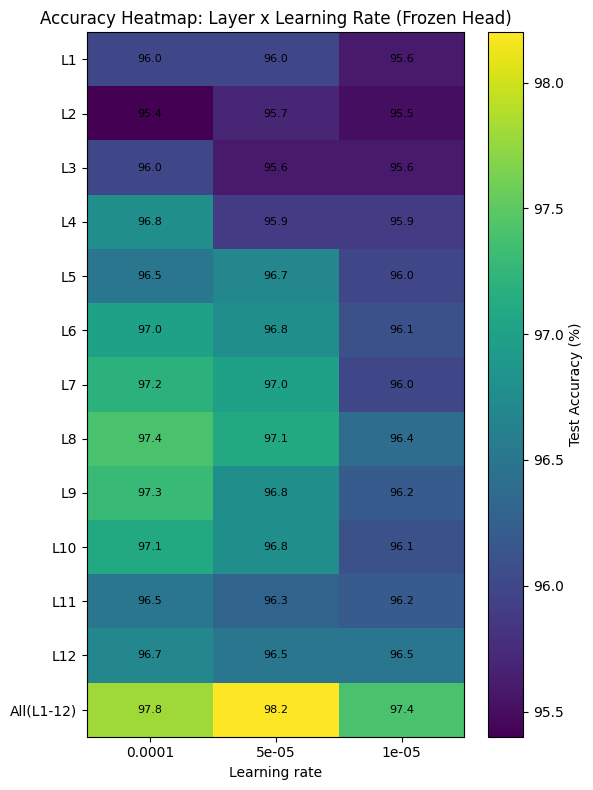

In [22]:
import numpy as np

heatmap_rows = list(layer_groups.keys())
heatmap_data = np.zeros((len(heatmap_rows), len(LR_GRID)))
for i, name in enumerate(heatmap_rows):
    for j, lr in enumerate(LR_GRID):
        heatmap_data[i, j] = next(r['test_acc'] for r in results if r['name'] == name and r['lr'] == lr)

fig, ax = plt.subplots(figsize=(6, 8))
im = ax.imshow(heatmap_data, cmap='viridis', aspect='auto')
ax.set_xticks(range(len(LR_GRID))); ax.set_xticklabels([str(lr) for lr in LR_GRID])
ax.set_yticks(range(len(heatmap_rows))); ax.set_yticklabels(heatmap_rows)
ax.set_xlabel('Learning rate'); ax.set_title('Accuracy Heatmap: Layer x Learning Rate (Frozen Head)')
for i in range(len(heatmap_rows)):
    for j in range(len(LR_GRID)):
        ax.text(j, i, f'{heatmap_data[i,j]:.1f}', ha='center', va='center',
                color='white' if heatmap_data[i,j] < heatmap_data.max()*0.7 else 'black', fontsize=8)
plt.colorbar(im, label='Test Accuracy (%)')
plt.tight_layout()
plt.savefig('tsv_frozen_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


### Best Learning Rate per Layer

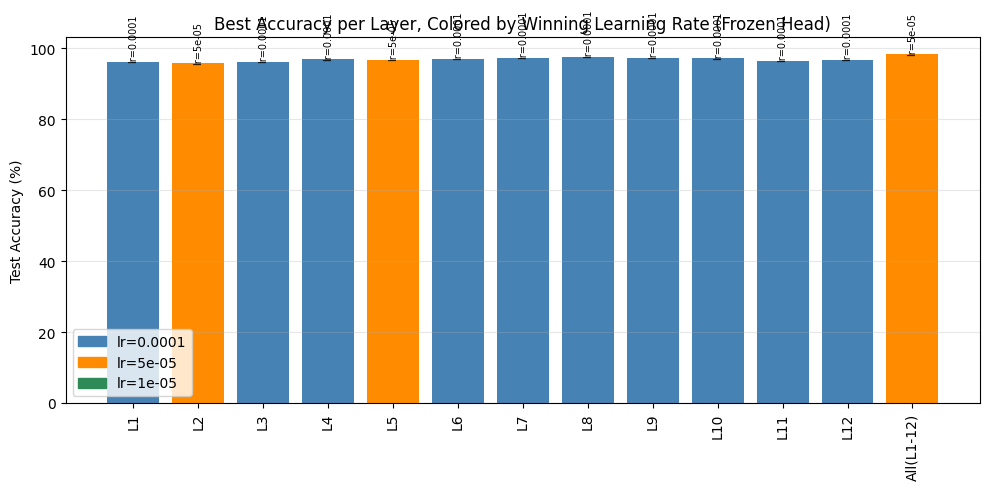

In [23]:
best_lr_per_layer = {}
for name in layer_groups.keys():
    layer_results = [r for r in results if r['name'] == name]
    best = max(layer_results, key=lambda r: r['test_acc'])
    best_lr_per_layer[name] = best

fig, ax = plt.subplots(figsize=(10, 5))
names = list(best_lr_per_layer.keys())
accs = [best_lr_per_layer[n]['test_acc'] for n in names]
lrs = [best_lr_per_layer[n]['lr'] for n in names]
colors = {LR_GRID[0]: 'steelblue', LR_GRID[1]: 'darkorange', LR_GRID[2]: 'seagreen'}
bars = ax.bar(names, accs, color=[colors[lr] for lr in lrs])
ax.set_title('Best Accuracy per Layer, Colored by Winning Learning Rate (Frozen Head)')
ax.set_ylabel('Test Accuracy (%)')
ax.tick_params(axis='x', rotation=90); ax.grid(True, alpha=0.3, axis='y')
for b, lr in zip(bars, lrs):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'lr={lr}', ha='center', fontsize=7, rotation=90)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=colors[lr], label=f'lr={lr}') for lr in LR_GRID])
plt.tight_layout()
plt.savefig('tsv_frozen_best_lr_per_layer.png', dpi=150, bbox_inches='tight')
plt.show()


### Stability View: Mean +/- Std Across Learning Rates, per Layer

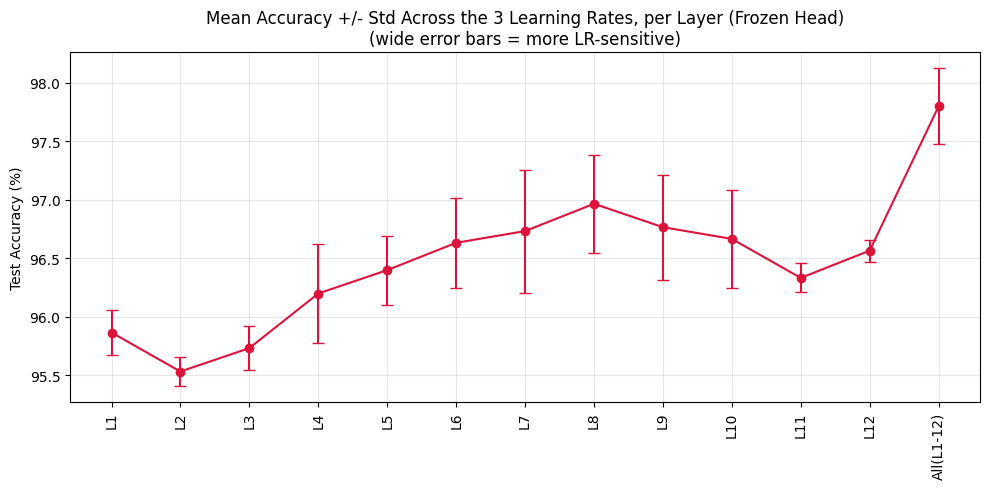

In [24]:
means, stds, stability_names = [], [], list(layer_groups.keys())
for name in stability_names:
    accs_for_name = [r['test_acc'] for r in results if r['name'] == name]
    means.append(np.mean(accs_for_name))
    stds.append(np.std(accs_for_name))

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(stability_names, means, yerr=stds, marker='o', capsize=4, color='crimson')
ax.set_title('Mean Accuracy +/- Std Across the 3 Learning Rates, per Layer (Frozen Head)\n(wide error bars = more LR-sensitive)')
ax.set_ylabel('Test Accuracy (%)')
ax.tick_params(axis='x', rotation=90); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tsv_frozen_stability.png', dpi=150, bbox_inches='tight')
plt.show()


### F1 Score (companion to the accuracy plot)

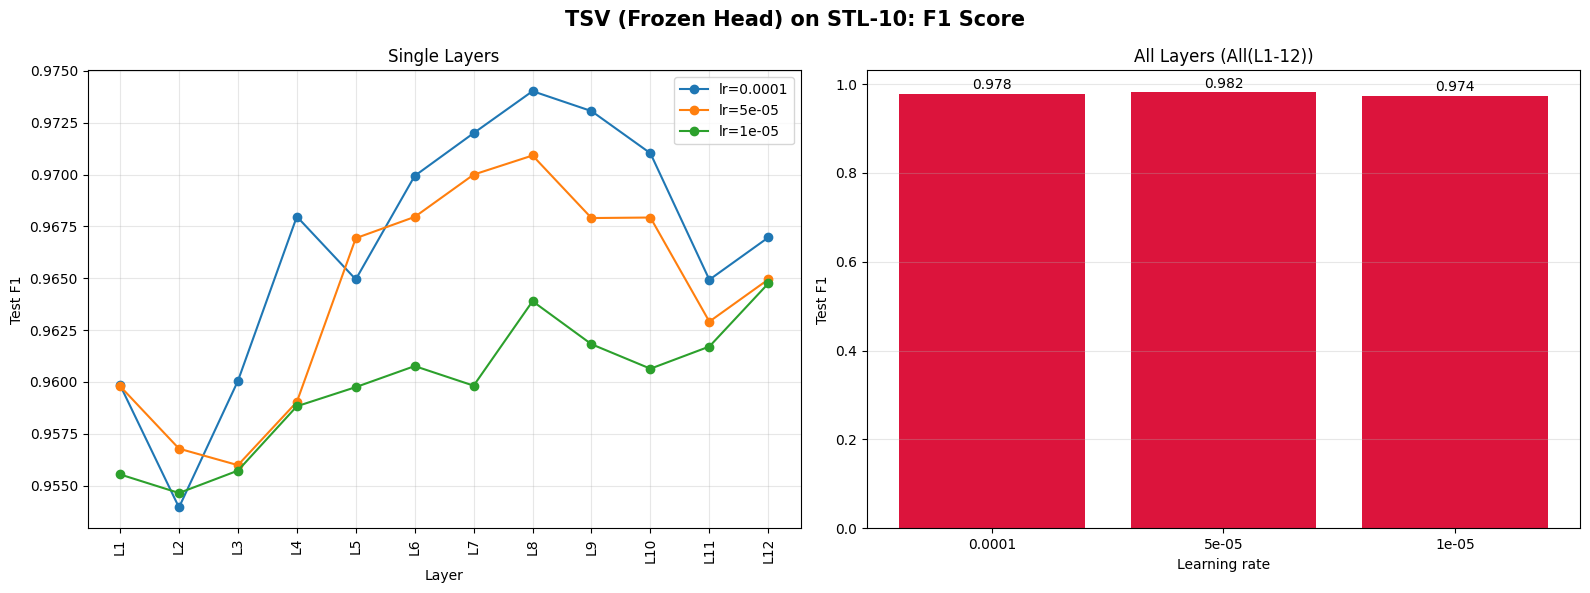

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('TSV (Frozen Head) on STL-10: F1 Score', fontsize=15, fontweight='bold')

for lr in LR_GRID:
    ys = [next(r['test_f1'] for r in singles_results if r['name'] == n and r['lr'] == lr) for n in names_order]
    axes[0].plot(names_order, ys, marker='o', label=f'lr={lr}')
axes[0].set_title('Single Layers'); axes[0].set_xlabel('Layer'); axes[0].set_ylabel('Test F1')
axes[0].tick_params(axis='x', rotation=90); axes[0].grid(True, alpha=0.3); axes[0].legend()

bar_f1s = [next(r['test_f1'] for r in all_layers_results if r['lr'] == lr) for lr in LR_GRID]
bars = axes[1].bar([str(lr) for lr in LR_GRID], bar_f1s, color='crimson')
axes[1].set_title(f'All Layers ({all_name})'); axes[1].set_xlabel('Learning rate'); axes[1].set_ylabel('Test F1')
axes[1].grid(True, alpha=0.3, axis='y')
for b in bars:
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{b.get_height():.3f}', ha='center')

plt.tight_layout()
plt.savefig('tsv_frozen_f1.png', dpi=150, bbox_inches='tight')
plt.show()


### Training Time and Accuracy-vs-Parameters Efficiency

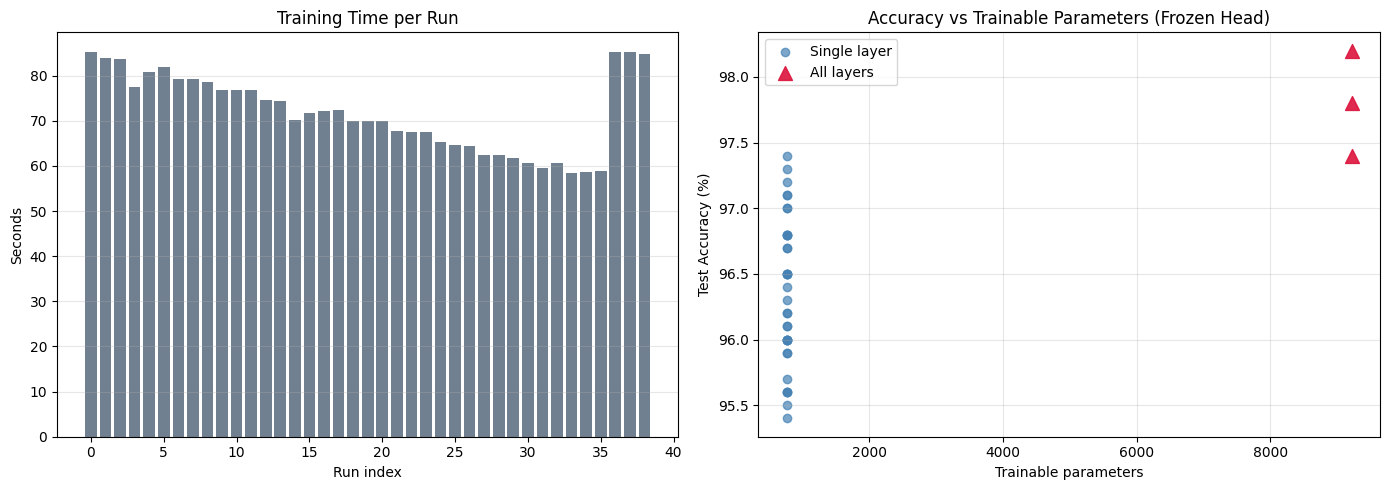

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

time_vals = [r['time_seconds'] for r in results]
axes[0].bar(range(len(results)), time_vals, color='slategray')
axes[0].set_title('Training Time per Run')
axes[0].set_xlabel('Run index'); axes[0].set_ylabel('Seconds')
axes[0].grid(True, alpha=0.3, axis='y')

params = [r['trainable_params'] for r in results]
accs = [r['test_acc'] for r in results]
is_all = ['All' in r['name'] for r in results]
axes[1].scatter([p for p,a in zip(params,is_all) if not a], [ac for ac,a in zip(accs,is_all) if not a],
                label='Single layer', alpha=0.7, color='steelblue')
axes[1].scatter([p for p,a in zip(params,is_all) if a], [ac for ac,a in zip(accs,is_all) if a],
                label='All layers', alpha=0.9, color='crimson', marker='^', s=100)
axes[1].set_title('Accuracy vs Trainable Parameters (Frozen Head)')
axes[1].set_xlabel('Trainable parameters'); axes[1].set_ylabel('Test Accuracy (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tsv_frozen_time_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()


### t-SNE Embedding Visualization (best vs. worst config)

Same idea as the trainable-head version, adapted for the frozen head's
embedding path: `vision_model -> pooler_output -> visual_projection`
(the actual space the frozen text embeddings live in), rather than the
raw CLS token a trainable classifier would see.

Extracting embeddings for BEST config: All(L1-12) lr=5e-05 (retraining briefly)...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Extracting embeddings for WORST config: L2 lr=0.0001 (retraining briefly)...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Running t-SNE (this takes a moment)...


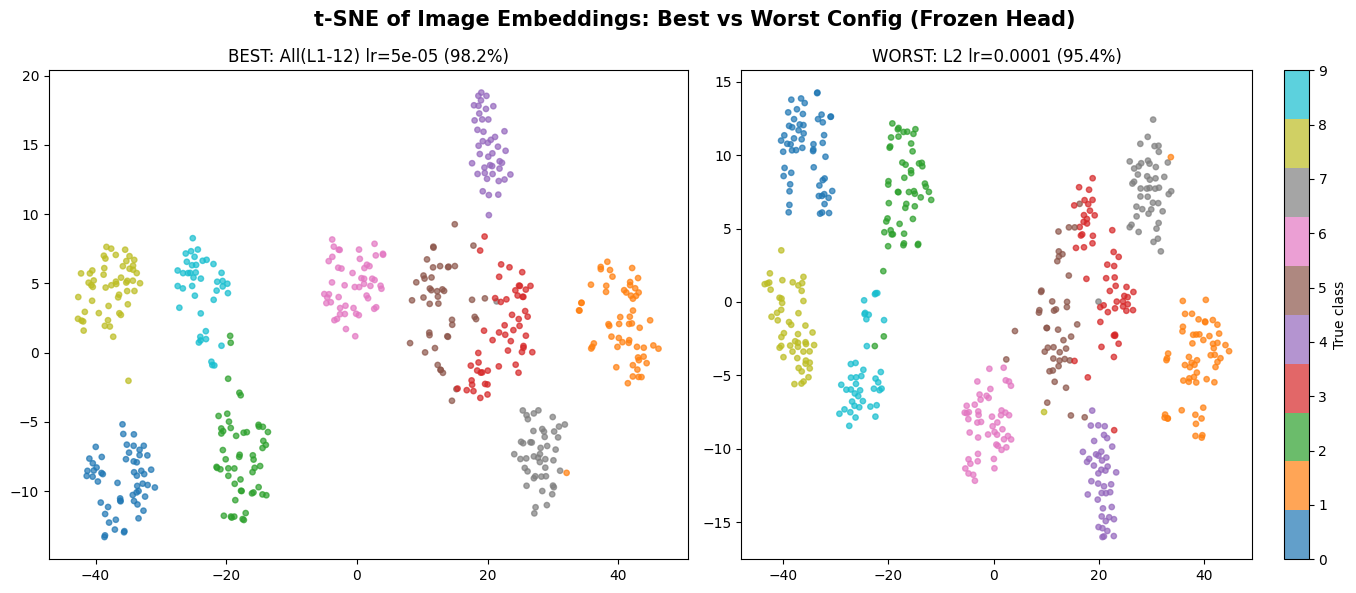

In [27]:
from sklearn.manifold import TSNE

worst_result = min(results, key=lambda r: r['test_acc'])

def extract_embeddings_frozen(layer_indices, where, lam, lr, n_samples=500):
    """Build the given frozen-head config, run a batch of test images
    through it, and return (projected embeddings, labels)."""
    m = TSVClassificationModelFrozenHead(model_name=OPENCLIP_MODEL_NAME, class_names=STL10_CLASSES,
                                          layer_indices=layer_indices, lam=lam, where=where).to(device)
    opt = optim.AdamW(m.trainable_parameters(), lr=lr, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss()
    for epoch in range(EPOCHS):
        train_epoch(m, train_loader, opt, crit, device, epoch, EPOCHS)

    m.eval()
    embeddings, labels = [], []
    with torch.no_grad():
        count = 0
        for images, lbls in test_loader:
            images = resize_images(images, target_size=224).to(device)
            vision_outputs = m.clip.vision_model(pixel_values=images)
            pooled = vision_outputs.pooler_output
            feats = m.clip.visual_projection(pooled)  # same projected space as the frozen text embeddings
            embeddings.append(feats.cpu().numpy())
            labels.append(lbls.numpy())
            count += images.size(0)
            if count >= n_samples:
                break
    del m, opt
    torch.cuda.empty_cache()
    return np.concatenate(embeddings)[:n_samples], np.concatenate(labels)[:n_samples]


print(f"Extracting embeddings for BEST config: {best_result['name']} lr={best_result['lr']} (retraining briefly)...")
best_emb, best_labels = extract_embeddings_frozen(best_result['layer_indices'], best_result['where'],
                                                    best_result['lam'], best_result['lr'])

print(f"Extracting embeddings for WORST config: {worst_result['name']} lr={worst_result['lr']} (retraining briefly)...")
worst_emb, worst_labels = extract_embeddings_frozen(worst_result['layer_indices'], worst_result['where'],
                                                      worst_result['lam'], worst_result['lr'])

print("Running t-SNE (this takes a moment)...")
best_2d = TSNE(n_components=2, random_state=42, init='pca').fit_transform(best_emb)
worst_2d = TSNE(n_components=2, random_state=42, init='pca').fit_transform(worst_emb)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc1 = axes[0].scatter(best_2d[:,0], best_2d[:,1], c=best_labels, cmap='tab10', s=15, alpha=0.7)
axes[0].set_title(f"BEST: {best_result['name']} lr={best_result['lr']} ({best_result['test_acc']:.1f}%)")
sc2 = axes[1].scatter(worst_2d[:,0], worst_2d[:,1], c=worst_labels, cmap='tab10', s=15, alpha=0.7)
axes[1].set_title(f"WORST: {worst_result['name']} lr={worst_result['lr']} ({worst_result['test_acc']:.1f}%)")
fig.suptitle('t-SNE of Image Embeddings: Best vs Worst Config (Frozen Head)', fontsize=15, fontweight='bold')
plt.colorbar(sc2, ax=axes[1], label='True class')
plt.tight_layout()
plt.savefig('tsv_frozen_tsne.png', dpi=150, bbox_inches='tight')
plt.show()


### Save Final Results

In [28]:
import shutil

final_summary = {
    'results': results,
    'best': best_result,
    'layer_groups_tested': {k: v for k, v in layer_groups.items()},
    'lr_grid': LR_GRID,
    'epochs': EPOCHS,
    'total_time_minutes': sweep_elapsed / 60,
}

with open(RESULTS_DIR / save_name('tsv_frozen_singles_all_study', 'json'), 'w') as f:
    json.dump(final_summary, f, indent=2)

all_pngs = [
    'tsv_frozen_singles_all_stl10.png',
    'tsv_frozen_heatmap.png',
    'tsv_frozen_best_lr_per_layer.png',
    'tsv_frozen_stability.png',
    'tsv_frozen_f1.png',
    'tsv_frozen_time_efficiency.png',
    'tsv_frozen_tsne.png',
]
for fname in all_pngs:
    base = fname.rsplit('.', 1)[0]
    shutil.copy(fname, RESULTS_DIR / save_name(base, 'png'))

CHECKPOINT_PATH.unlink(missing_ok=True)

print(f"\u2713 Final results + plot saved to {RESULTS_DIR}")
print(f"  Best config: {best_result['name']}, lr={best_result['lr']} -> {best_result['test_acc']:.2f}%")


✓ Final results + plot saved to /content/drive/MyDrive/PEFT_Results_STL10_TSV_Frozen
  Best config: All(L1-12), lr=5e-05 -> 98.20%
